Libraries Imported Successfully
Input Shape: torch.Size([6, 4])
Forward Output Shape: torch.Size([6, 5])
Backward Output Shape: torch.Size([6, 5])
BiLSTM Output Shape: torch.Size([6, 10])

BiLSTM Output:
tensor([[-0.0856, -0.0395, -0.1036, -0.0623,  0.0051,  0.0683, -0.0102,  0.1471,
          0.0068,  0.1055],
        [-0.0822, -0.0364, -0.0341, -0.1437, -0.1022,  0.0336,  0.0457,  0.0541,
          0.1239,  0.0012],
        [-0.0485, -0.0280, -0.0138, -0.0440, -0.0750,  0.0081,  0.0075, -0.0235,
          0.0549, -0.0744],
        [-0.0179,  0.0143, -0.0455, -0.1667, -0.0573,  0.0141, -0.0341, -0.0061,
         -0.0023, -0.0864],
        [ 0.0025,  0.0118,  0.0114, -0.1163, -0.0543, -0.0060,  0.0029,  0.0064,
          0.0181,  0.0350],
        [ 0.0139,  0.0191, -0.0031, -0.0830, -0.0222, -0.0052, -0.0108, -0.0289,
         -0.0016, -0.0504]])


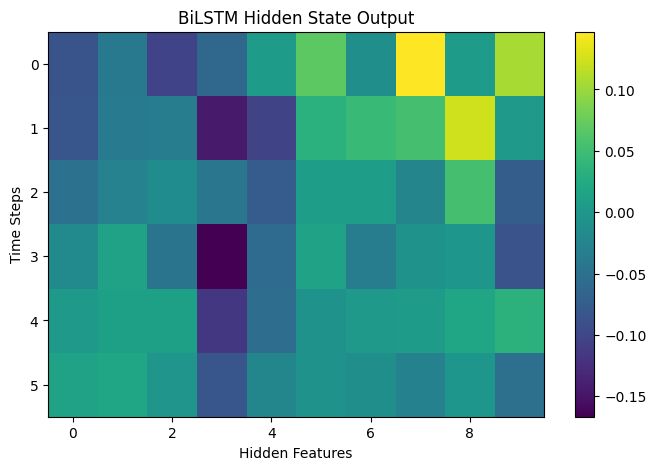


BiLSTM Experiment Completed


In [1]:
# ==========================================================
# TASK 6
# Bidirectional LSTM Cell from Scratch
# ==========================================================

# ----------------------------------------------------------
# Step 1 - Import Libraries
# ----------------------------------------------------------

import torch
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")


# ----------------------------------------------------------
# Step 2 - Create Input Sequence
# ----------------------------------------------------------

torch.manual_seed(42)

sequence_length = 6
input_size = 4
hidden_size = 5

X = torch.randn(
    sequence_length,
    input_size
)

print("Input Shape:", X.shape)


# ----------------------------------------------------------
# Step 3 - Create LSTM Parameters
# ----------------------------------------------------------

def create_parameters():

    W = torch.randn(
        input_size + hidden_size,
        4 * hidden_size
    ) * 0.1

    b = torch.zeros(
        1,
        4 * hidden_size
    )

    return W, b


# Forward direction parameters
W_forward, b_forward = create_parameters()

# Backward direction parameters
W_backward, b_backward = create_parameters()


# ----------------------------------------------------------
# Step 4 - Define Activation Functions
# ----------------------------------------------------------

def sigmoid(x):

    return 1 / (1 + torch.exp(-x))


# ----------------------------------------------------------
# Step 5 - LSTM Forward Direction
# ----------------------------------------------------------

def lstm_forward(X, W, b):

    h = torch.zeros(1, hidden_size)

    c = torch.zeros(1, hidden_size)

    outputs = []

    for t in range(X.shape[0]):

        x = X[t].reshape(1, -1)

        # Combine input and previous hidden state
        combined = torch.cat(
            [x, h],
            dim=1
        )

        gates = torch.matmul(
            combined,
            W
        ) + b

        # Split into four gates
        input_gate = sigmoid(
            gates[:, :hidden_size]
        )

        forget_gate = sigmoid(
            gates[:, hidden_size:2 * hidden_size]
        )

        output_gate = sigmoid(
            gates[:, 2 * hidden_size:3 * hidden_size]
        )

        cell_candidate = torch.tanh(
            gates[:, 3 * hidden_size:]
        )

        # Update cell state
        c = (
            forget_gate * c
            + input_gate * cell_candidate
        )

        # Update hidden state
        h = output_gate * torch.tanh(c)

        outputs.append(h)

    return torch.cat(outputs, dim=0)


# ----------------------------------------------------------
# Step 6 - LSTM Backward Direction
# ----------------------------------------------------------

def lstm_backward(X, W, b):

    h = torch.zeros(1, hidden_size)

    c = torch.zeros(1, hidden_size)

    outputs = []

    # Read sequence from the end
    for t in range(
        X.shape[0] - 1,
        -1,
        -1
    ):

        x = X[t].reshape(1, -1)

        combined = torch.cat(
            [x, h],
            dim=1
        )

        gates = torch.matmul(
            combined,
            W
        ) + b

        input_gate = sigmoid(
            gates[:, :hidden_size]
        )

        forget_gate = sigmoid(
            gates[:, hidden_size:2 * hidden_size]
        )

        output_gate = sigmoid(
            gates[:, 2 * hidden_size:3 * hidden_size]
        )

        cell_candidate = torch.tanh(
            gates[:, 3 * hidden_size:]
        )

        c = (
            forget_gate * c
            + input_gate * cell_candidate
        )

        h = output_gate * torch.tanh(c)

        outputs.append(h)

    # Reverse outputs so they match
    # the original sequence order
    outputs.reverse()

    return torch.cat(outputs, dim=0)


# ----------------------------------------------------------
# Step 7 - Run Forward LSTM
# ----------------------------------------------------------

forward_output = lstm_forward(
    X,
    W_forward,
    b_forward
)

print(
    "Forward Output Shape:",
    forward_output.shape
)


# ----------------------------------------------------------
# Step 8 - Run Backward LSTM
# ----------------------------------------------------------

backward_output = lstm_backward(
    X,
    W_backward,
    b_backward
)

print(
    "Backward Output Shape:",
    backward_output.shape
)


# ----------------------------------------------------------
# Step 9 - Combine Both Directions
# ----------------------------------------------------------

bilstm_output = torch.cat(
    [
        forward_output,
        backward_output
    ],
    dim=1
)

print(
    "BiLSTM Output Shape:",
    bilstm_output.shape
)


# ----------------------------------------------------------
# Step 10 - Display Output
# ----------------------------------------------------------

print("\nBiLSTM Output:")

print(
    bilstm_output
)


# ----------------------------------------------------------
# Step 11 - Visualize Output
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.imshow(
    bilstm_output.detach().numpy(),
    aspect="auto"
)

plt.xlabel("Hidden Features")

plt.ylabel("Time Steps")

plt.title("BiLSTM Hidden State Output")

plt.colorbar()

plt.show()


# ----------------------------------------------------------
# Step 12 - Experiment Completed
# ----------------------------------------------------------

print("\nBiLSTM Experiment Completed")